In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [ ]:
import pandas as pd
from google.colab import files
import os

# Check if the file already exists
file_path = 'konga_transactions.csv'
if not os.path.exists(file_path):
    print(f"The file '{file_path}' was not found. Please upload it.")
    uploaded = files.upload()
    if file_path not in uploaded:
        print(f"Error: '{file_path}' was not uploaded. Please ensure you upload the correct file.")
        # If the file is still not found after upload attempt, subsequent code might fail.
        # The `pd.read_csv` line below will likely re-raise FileNotFoundError if not uploaded.
    else:
        print(f"'{file_path}' uploaded successfully.")

df = pd.read_csv(file_path)
df.head()

,order_id,customer_id,order_date,city,payment_method,product,category,quantity,unit_price_ngn,line_total_ngn
0,KNG-2024-00002,CUST-2728,2024-04-29 07:35,Lagos,Card,JAMB CBT Guide,Books & Stationery,2,4200,8400
1,KNG-2024-00002,CUST-2728,2024-04-29 07:35,Lagos,Card,WAEC Past Questions,Books & Stationery,1,3500,3500
2,KNG-2024-00003,CUST-2393,2024-06-21 10:05,Lagos,Card,Dangote Sugar 1kg,Food & Groceries,1,2200,2200
3,KNG-2024-00004,CUST-2200,2024-07-04 13:45,Enugu,Bank Transfer,Lace Blouse,Fashion - Women,1,9500,9500
4,KNG-2024-00005,CUST-3603,2024-06-30 13:42,Enugu,Card,Resistance Bands,Sports & Fitness,1,5500,5500


In [ ]:
df.isnull().sum()

,0
order_id,0
customer_id,0
order_date,0
city,0
payment_method,0
product,0
category,0
quantity,0
unit_price_ngn,0
line_total_ngn,0


In [ ]:
customer_data = df.groupby('customer_id').agg({
    'order_id': 'count',
    'quantity': 'sum',
    'line_total_ngn': 'sum'
}).reset_index()

customer_data.columns = ['customer_id', 'order_count', 'total_quantity', 'total_spent']

customer_data.head()

,customer_id,order_count,total_quantity,total_spent
0,CUST-1000,3,4,32900
1,CUST-1001,2,2,43500
2,CUST-1002,2,2,14200
3,CUST-1006,3,3,137200
4,CUST-1007,2,2,5000


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = customer_data[['order_count', 'total_quantity', 'total_spent']]

X_scaled = scaler.fit_transform(X)

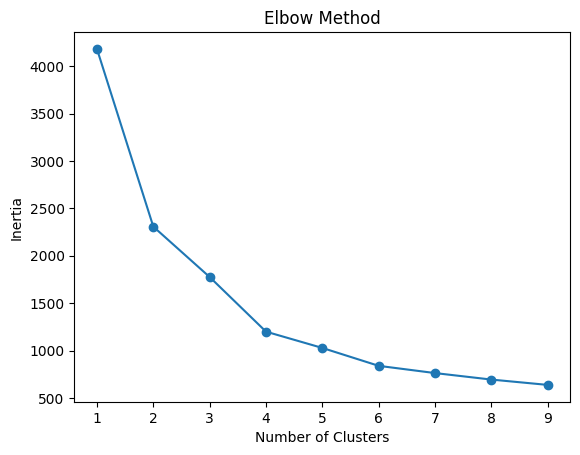

In [ ]:
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

import matplotlib.pyplot as plt

plt.plot(range(1, 10), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)

customer_data['cluster'] = kmeans.fit_predict(X_scaled)

customer_data.head()

,customer_id,order_count,total_quantity,total_spent,cluster
0,CUST-1000,3,4,32900,2
1,CUST-1001,2,2,43500,2
2,CUST-1002,2,2,14200,2
3,CUST-1006,3,3,137200,2
4,CUST-1007,2,2,5000,2


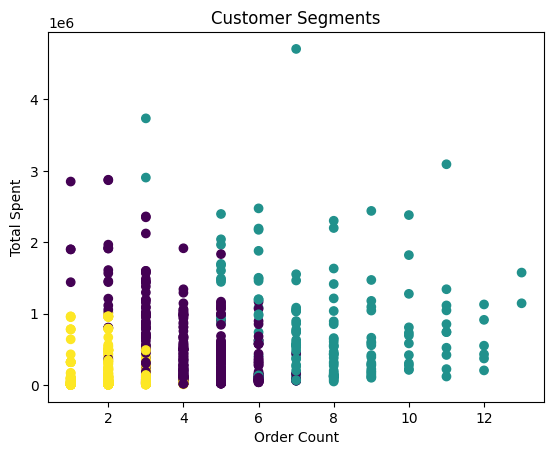

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(customer_data['order_count'], customer_data['total_spent'],
            c=customer_data['cluster'])

plt.xlabel('Order Count')
plt.ylabel('Total Spent')
plt.title('Customer Segments')
plt.show()

<Axes: xlabel='order_date'>

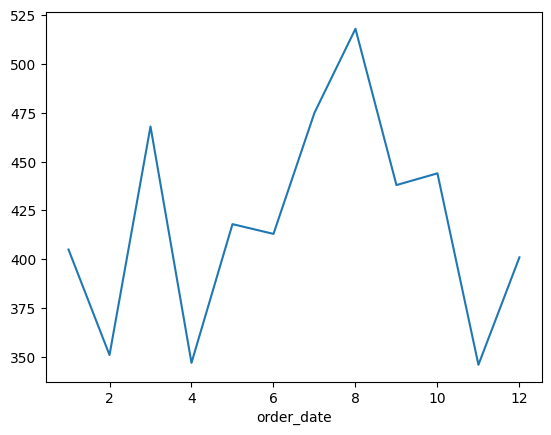

In [ ]:
df['city'].value_counts()
df['category'].value_counts()

df['order_date'] = pd.to_datetime(df['order_date'])
df.groupby(df['order_date'].dt.month).size().plot()

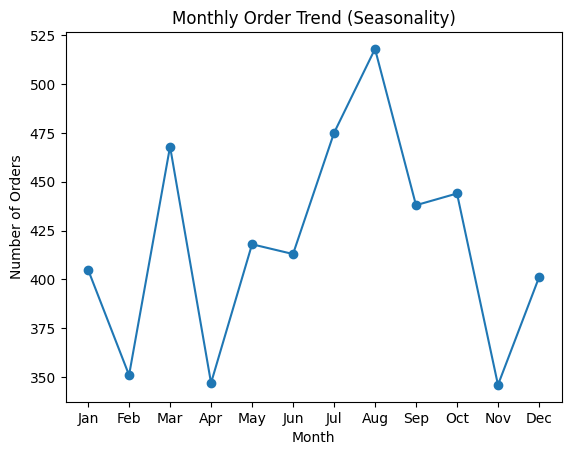

In [ ]:
monthly_orders = df.groupby(df['order_date'].dt.month).size()

monthly_orders.plot(marker='o')

plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.title('Monthly Order Trend (Seasonality)')
plt.xticks(range(1,13),
           ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

plt.show()

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [ ]:
import datetime as dt

latest_date = df['order_date'].max()

# Create recency separately (safer)
recency = df.groupby('customer_id')['order_date'] \
    .max().apply(lambda x: (latest_date - x).days)

# Add new features
customer_data['recency'] = recency.values
customer_data['avg_order_value'] = customer_data['total_spent'] / customer_data['order_count']
customer_data['orders_per_month'] = customer_data['order_count'] / 12

customer_data.head()

,customer_id,order_count,total_quantity,total_spent,cluster,recency,avg_order_value,orders_per_month
0,CUST-1000,3,4,32900,2,106,10966.666667,0.250000
1,CUST-1001,2,2,43500,2,359,21750.000000,0.166667
2,CUST-1002,2,2,14200,2,308,7100.000000,0.166667
3,CUST-1006,3,3,137200,2,304,45733.333333,0.250000
4,CUST-1007,2,2,5000,2,76,2500.000000,0.166667


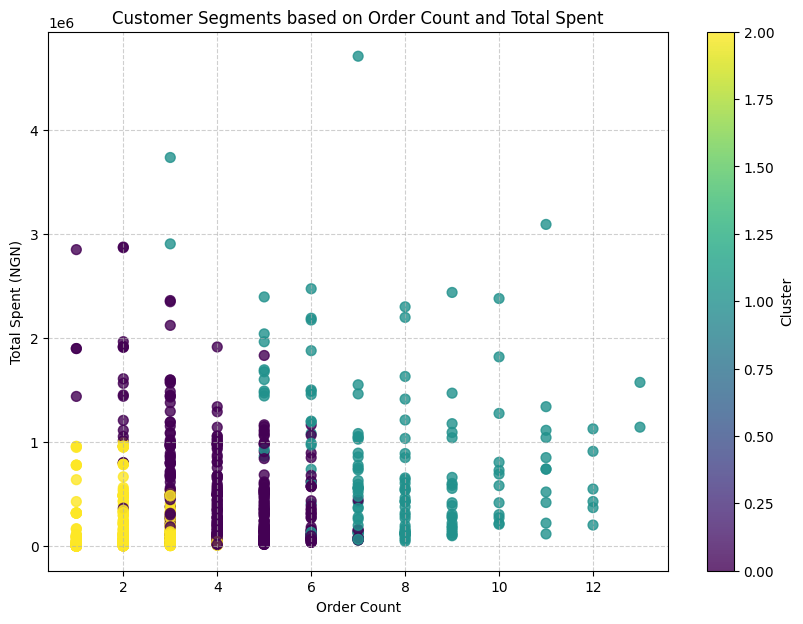

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.scatter(customer_data['order_count'], customer_data['total_spent'], c=customer_data['cluster'], cmap='viridis', s=50, alpha=0.8)
plt.xlabel('Order Count')
plt.ylabel('Total Spent (NGN)')
plt.title('Customer Segments based on Order Count and Total Spent')
plt.colorbar(label='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

This scatter plot visually represents the customer segments. You should be able to observe distinct groupings based on their 'Order Count' and 'Total Spent' colored by their assigned cluster. This helps to confirm the separation identified by the K-Means algorithm.

In [ ]:
cluster_characteristics = customer_data.groupby('cluster').agg({
    'order_count': 'mean',
    'total_quantity': 'mean',
    'total_spent': 'mean',
    'recency': 'mean',
    'avg_order_value': 'mean',
    'orders_per_month': 'mean'
}).reset_index()

display(cluster_characteristics)

,cluster,order_count,total_quantity,total_spent,recency,avg_order_value,orders_per_month
0,0,4.269155,6.225933,407095.481336,159.840864,131053.747310,0.355763
1,1,7.968354,11.759494,803938.607595,113.879747,119099.679708,0.664030
2,2,2.189821,2.826685,105992.434663,179.830812,55357.737276,0.182485


This table shows the average characteristics for each customer cluster. We can now interpret what each cluster represents based on these mean values. For example, a cluster with a low 'recency' and high 'total_spent' would represent recent, high-value customers.

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])

In [ ]:
customer_data = df.groupby('customer_id').agg({
    'order_id': 'count',
    'quantity': 'sum',
    'line_total_ngn': 'sum'
}).reset_index()

customer_data.columns = ['customer_id', 'order_count', 'total_quantity', 'total_spent']

customer_data.head()

,customer_id,order_count,total_quantity,total_spent
0,CUST-1000,3,4,32900
1,CUST-1001,2,2,43500
2,CUST-1002,2,2,14200
3,CUST-1006,3,3,137200
4,CUST-1007,2,2,5000


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X = customer_data[['order_count', 'total_quantity', 'total_spent']]

X_scaled = scaler.fit_transform(X)

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)

customer_data['cluster'] = kmeans.fit_predict(X_scaled)

customer_data.head()

,customer_id,order_count,total_quantity,total_spent,cluster
0,CUST-1000,3,4,32900,2
1,CUST-1001,2,2,43500,2
2,CUST-1002,2,2,14200,2
3,CUST-1006,3,3,137200,2
4,CUST-1007,2,2,5000,2


In [ ]:
import datetime as dt

latest_date = df['order_date'].max()

# Create recency separately (safer)
recency = df.groupby('customer_id')['order_date'] \
    .max().apply(lambda x: (latest_date - x).days)

# Add new features
customer_data['recency'] = recency.values
customer_data['avg_order_value'] = customer_data['total_spent'] / customer_data['order_count']
customer_data['orders_per_month'] = customer_data['order_count'] / 12

customer_data.head()

,customer_id,order_count,total_quantity,total_spent,cluster,recency,avg_order_value,orders_per_month
0,CUST-1000,3,4,32900,2,106,10966.666667,0.250000
1,CUST-1001,2,2,43500,2,359,21750.000000,0.166667
2,CUST-1002,2,2,14200,2,308,7100.000000,0.166667
3,CUST-1006,3,3,137200,2,304,45733.333333,0.250000
4,CUST-1007,2,2,5000,2,76,2500.000000,0.166667


In [ ]:
customer_data = df.groupby('customer_id').agg({
    'order_id': 'count',
    'quantity': 'sum',
    'line_total_ngn': 'sum'
}).reset_index()

customer_data.columns = ['customer_id', 'order_count', 'total_quantity', 'total_spent']

customer_data.head()

,customer_id,order_count,total_quantity,total_spent
0,CUST-1000,3,4,32900
1,CUST-1001,2,2,43500
2,CUST-1002,2,2,14200
3,CUST-1006,3,3,137200
4,CUST-1007,2,2,5000


In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)

customer_data['cluster'] = kmeans.fit_predict(X_scaled)

customer_data.head()

,customer_id,order_count,total_quantity,total_spent,cluster,recency,avg_order_value,orders_per_month
0,CUST-1000,3,4,32900,2,106,10966.666667,0.250000
1,CUST-1001,2,2,43500,2,359,21750.000000,0.166667
2,CUST-1002,2,2,14200,2,308,7100.000000,0.166667
3,CUST-1006,3,3,137200,2,304,45733.333333,0.250000
4,CUST-1007,2,2,5000,2,76,2500.000000,0.166667


In [ ]:
import datetime as dt
import pandas as pd

df['order_date'] = pd.to_datetime(df['order_date'])

latest_date = df['order_date'].max()

# Create recency separately (safer)
recency = df.groupby('customer_id')['order_date'] \
    .max().apply(lambda x: (latest_date - x).days)

# Add new features
customer_data['recency'] = recency.values
customer_data['avg_order_value'] = customer_data['total_spent'] / customer_data['order_count']
customer_data['orders_per_month'] = customer_data['order_count'] / 12

customer_data.head()

,customer_id,order_count,total_quantity,total_spent,cluster,recency,avg_order_value,orders_per_month
0,CUST-1000,3,4,32900,2,106,10966.666667,0.250000
1,CUST-1001,2,2,43500,2,359,21750.000000,0.166667
2,CUST-1002,2,2,14200,2,308,7100.000000,0.166667
3,CUST-1006,3,3,137200,2,304,45733.333333,0.250000
4,CUST-1007,2,2,5000,2,76,2500.000000,0.166667


In [ ]:
from sklearn.preprocessing import StandardScaler

# Drop customer_id (not needed for modeling)
X = customer_data.drop('customer_id', axis=1)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

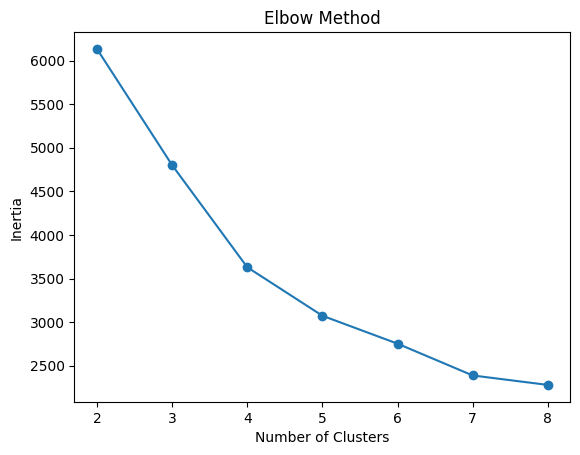

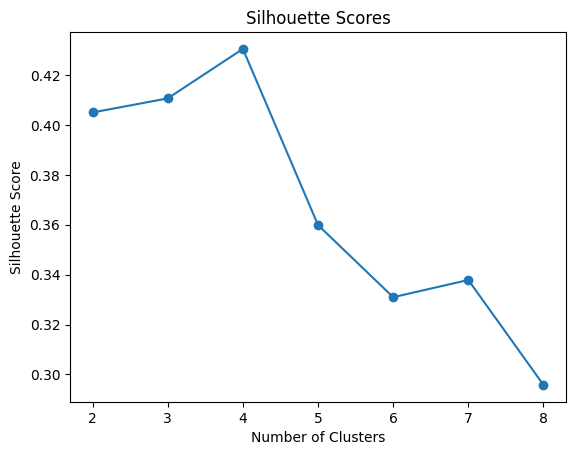

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette_scores = []

K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Elbow Plot
plt.plot(K_range, inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

# Silhouette Plot
plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores')
plt.show()

In [ ]:
cluster_profile = customer_data.groupby('cluster').mean(numeric_only=True)

cluster_profile

,order_count,total_quantity,total_spent,recency,avg_order_value,orders_per_month
cluster,,,,,,
0,4.245614,6.231969,440999.805068,161.009747,139294.216560,0.353801
1,2.189821,2.826685,105992.434663,179.830812,55357.737276,0.182485
2,8.142857,11.883117,701305.194805,108.792208,91338.790128,0.678571


In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)

db_labels = dbscan.fit_predict(X_scaled)

# Add to your dataset
customer_data['dbscan_cluster'] = db_labels

customer_data.head()

,customer_id,order_count,total_quantity,total_spent,cluster,recency,avg_order_value,orders_per_month,dbscan_cluster
0,CUST-1000,3,4,32900,1,106,10966.666667,0.250000,0
1,CUST-1001,2,2,43500,1,359,21750.000000,0.166667,1
2,CUST-1002,2,2,14200,1,308,7100.000000,0.166667,1
3,CUST-1006,3,3,137200,1,304,45733.333333,0.250000,0
4,CUST-1007,2,2,5000,1,76,2500.000000,0.166667,1


In [ ]:
customer_data['dbscan_cluster'].value_counts()

,count
dbscan_cluster,
-1,317
1,294
0,221
8,133
5,132
2,116
3,35
4,33
10,19


In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

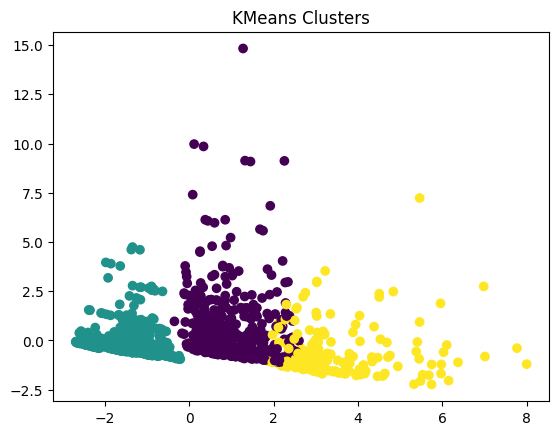

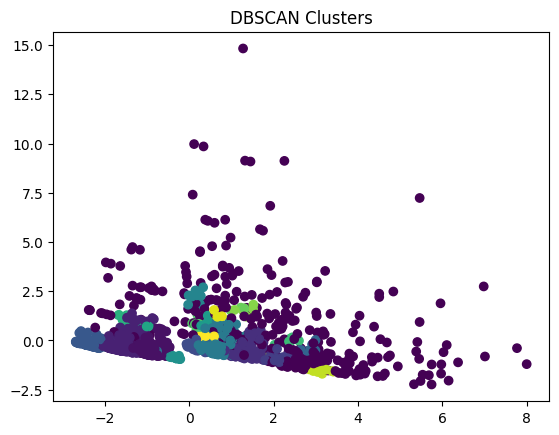

In [ ]:
import matplotlib.pyplot as plt

# KMeans
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=customer_data['cluster'])
plt.title('KMeans Clusters')
plt.show()

# DBSCAN
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=customer_data['dbscan_cluster'])
plt.title('DBSCAN Clusters')
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import datetime as dt
import pandas as pd
from sklearn.cluster import KMeans, DBSCAN

# Load the DataFrame to ensure 'df' is defined
df = pd.read_csv('konga_transactions.csv')

# Ensure df['order_date'] is datetime type
df['order_date'] = pd.to_datetime(df['order_date'])

# Re-create customer_data with aggregated features
customer_data = df.groupby('customer_id').agg({
    'order_id': 'count',
    'quantity': 'sum',
    'line_total_ngn': 'sum'
}).reset_index()
customer_data.columns = ['customer_id', 'order_count', 'total_quantity', 'total_spent']

# Add new features
latest_date = df['order_date'].max()
recency = df.groupby('customer_id')['order_date'].max().apply(lambda x: (latest_date - x).days)
customer_data['recency'] = recency.values
customer_data['avg_order_value'] = customer_data['total_spent'] / customer_data['order_count']
customer_data['orders_per_month'] = customer_data['order_count'] / 12

# Scale the data
X = customer_data.drop('customer_id', axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto')
customer_data['cluster'] = kmeans.fit_predict(X_scaled)

# DBSCAN clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)
customer_data['dbscan_cluster'] = db_labels


kmeans_score = silhouette_score(X_scaled, customer_data['cluster'])

# Only calculate DBSCAN score if more than 1 cluster exists
if len(set(db_labels)) > 1:
    dbscan_score = silhouette_score(X_scaled, db_labels)
else:
    dbscan_score = -1

kmeans_score, dbscan_score

(np.float64(0.4157490652029951), np.float64(-0.06866623040620683))

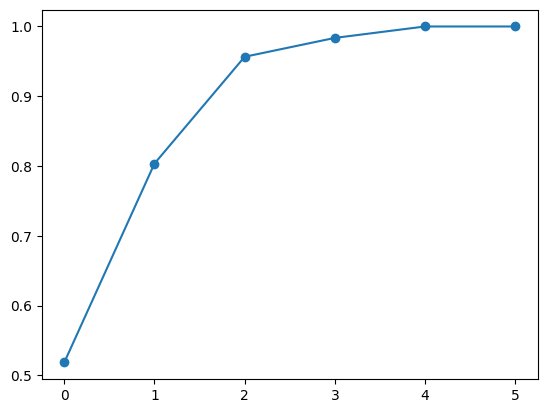

In [ ]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(X_scaled)

plt.plot(pca.explained_variance_ratio_.cumsum(), marker='o')

In [ ]:
# Apply PCA with 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Re-run KMeans
kmeans_pca = KMeans(n_clusters=3, random_state=42)
pca_labels = kmeans_pca.fit_predict(X_pca)

# Compare silhouette scores
from sklearn.metrics import silhouette_score

original_score = silhouette_score(X_scaled, customer_data['cluster'])
pca_score = silhouette_score(X_pca, pca_labels)

original_score, pca_score

(np.float64(0.4157490652029951), np.float64(0.5382957041811858))

In [ ]:
merged = df.merge(customer_data[['customer_id','cluster']], on='customer_id')

merged[merged['cluster']==2]['city'].value_counts()

,count
city,
Lagos,768
Abuja,361
Port Harcourt,320
Kano,161
Ibadan,152
Enugu,148
Kaduna,77
Owerri,62
Benin City,62
